In [18]:
import os
import sys
import glob
import random
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from rasterio.errors import NotGeoreferencedWarning

# ignore this specific rasterio warning
warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)

# look in parent directory for the src folder
sys.path.append('..')

# imports from the src folder
from src.tiling import generate_tiles

In [ ]:
# define dataset parent directory
data_dir = os.path.abspath("../data/cropped")

In [ ]:
# define the directories for stitched images and masks
stitched_img_dir = os.path.join(data_dir, 'stitched/images')
stitched_mask_dir = os.path.join(data_dir, 'stitched/masks')

# define output directories for tiled images and masks
out_img_dir_fns = os.path.join(data_dir, 'tiled/images_fns')
out_mask_dir_fns = os.path.join(data_dir, 'tiled/masks_fns')

# create directories if necessary
os.makedirs(out_img_dir_fns, exist_ok=True)
os.makedirs(out_mask_dir_fns, exist_ok=True)

In [20]:
# this cell generates tiles for all chaos regions in the stitched images directory

# get a list of all stitched TIFF images
stitched_images = sorted(glob.glob(os.path.join(stitched_img_dir, "*.tif")))

# print the number of stitched images found
print(f"Found {len(stitched_images)} regions to tile. Starting...\n")

# loop through the stitched images
for img_path in stitched_images:
    # find the matching mask files
    basename = os.path.basename(img_path)
    mask_path = os.path.join(stitched_mask_dir, basename)
    
    # check that the mask exists
    if os.path.exists(mask_path):
        # call generate tiles function with Flip'n'Slide toggled on
        generate_tiles(
            img_path=img_path, 
            mask_path=mask_path, 
            out_img_dir=out_img_dir_fns, 
            out_mask_dir=out_mask_dir_fns,
            chip_size=256, 
            stride=128,
            apply_flipnslide=True
        )
    else:
        print(f"[ERROR] No matching mask found for {basename}")

# print loop completion message
print("\nFinished generating all tiles")

Found 20 regions to tile. Starting...

Generated 180 Flip'n'Slide chips for Chaos_A
Generated 24 Flip'n'Slide chips for Chaos_B
Generated 12 Flip'n'Slide chips for Chaos_C
Generated 168 Flip'n'Slide chips for Chaos_Co
Generated 6 Flip'n'Slide chips for Chaos_D
Generated 48 Flip'n'Slide chips for Chaos_E
Generated 24 Flip'n'Slide chips for Chaos_F
Generated 24 Flip'n'Slide chips for Chaos_G
Generated 12 Flip'n'Slide chips for Chaos_H
Generated 54 Flip'n'Slide chips for Chaos_I
Generated 186 Flip'n'Slide chips for Chaos_aa
Generated 384 Flip'n'Slide chips for Chaos_bb
Generated 72 Flip'n'Slide chips for Chaos_dd
Generated 12 Flip'n'Slide chips for Chaos_ee
Generated 12 Flip'n'Slide chips for Chaos_ff
Generated 96 Flip'n'Slide chips for Chaos_gg
Generated 114 Flip'n'Slide chips for Chaos_hh
Generated 150 Flip'n'Slide chips for Chaos_ii
Generated 90 Flip'n'Slide chips for Chaos_jj
Generated 18 Flip'n'Slide chips for Chaos_kk

Finished generating all tiles


In [21]:
# run this cell for statistical summary of generated tiles

# create list of generate mask tiles
generated_masks = glob.glob(os.path.join(out_mask_dir_fns, "*.tif"))

# initialize empty list to store stats
records = []

# loop though mask tiles
for mask_path in generated_masks:
    filename = os.path.basename(mask_path)
    
    # extract the region name
    parts = filename.split('_')
    region_name = f"{parts[0]}_{parts[1]}" if len(parts) >= 2 else "Unknown"

    with rasterio.open(mask_path) as src:
        mask_data = src.read(1)
        
    # count unique block IDs
    unique_ids = np.unique(mask_data)
    block_count = len(unique_ids[unique_ids != 0])

    # add counts to records
    records.append({
        "filename": filename,
        "region": region_name,
        "block_count": block_count,
        "is_empty": block_count == 0
    })

# build pandas dataframe
df_chips = pd.DataFrame(records)

# calculate total dataset summary statistics
total_chips = len(df_chips)
empty_chips = df_chips['is_empty'].sum()
chips_with_blocks = total_chips - empty_chips

print("--- Overall Dataset Stats ---")
print(f"Total Chips Generated: {total_chips}")
print(f"Chips with Blocks (Positive): {chips_with_blocks} ({(chips_with_blocks/total_chips)*100:.1f}%)")
print(f"Empty Chips (Negative): {empty_chips} ({(empty_chips/total_chips)*100:.1f}%)")
print(f"Average Blocks per Positive Chip: {df_chips[df_chips['block_count'] > 0]['block_count'].mean():.1f}")
print(f"Max Blocks in a single Chip: {df_chips['block_count'].max()}")

# show stats by region
print("\n--- Region Stats ---")
region_stats = df_chips.groupby('region').agg(
    Total_Chips=('filename', 'count'),
    Empty_Chips=('is_empty', 'sum'),
    Avg_Blocks_Per_Chip=('block_count', 'mean')
).round(1)

display(region_stats)

--- Overall Dataset Stats ---
Total Chips Generated: 1686
Chips with Blocks (Positive): 1674 (99.3%)
Empty Chips (Negative): 12 (0.7%)
Average Blocks per Positive Chip: 26.8
Max Blocks in a single Chip: 103

--- Region Stats ---


,Total_Chips,Empty_Chips,Avg_Blocks_Per_Chip
region,,,
Chaos_A,180,0,38.2
Chaos_B,24,0,58.0
Chaos_C,12,0,64.5
Chaos_Co,168,0,25.1
Chaos_D,6,0,66.0
Chaos_E,48,0,35.6
Chaos_F,24,0,23.5
Chaos_G,24,0,19.5
Chaos_H,12,0,16.0


In [22]:
# run this cell for statistical summary of generated tiles

# create list of generate mask tiles
generated_masks = glob.glob(os.path.join(out_mask_dir_fns, "*.tif"))
print(f"Analyzing {len(generated_masks)} generated chips...\n")

# initialize empty list to store stats
records = []

# loop though mask tiles
for mask_path in generated_masks:
    filename = os.path.basename(mask_path)
    
    # extract the region name
    parts = filename.split('_')
    region_name = f"{parts[0]}_{parts[1]}" if len(parts) >= 2 else "Unknown"

    with rasterio.open(mask_path) as src:
        mask_data = src.read(1)
        total_pixels = mask_data.size # (e.g., 256 x 256 = 65,536)
        
    # count unique block IDs (excluding 0)
    unique_ids = np.unique(mask_data)
    unique_ids = unique_ids[unique_ids != 0]
    block_count = len(unique_ids)

    # Calculate block sizes and coverage
    if block_count > 0:
        # np.bincount rapidly counts how many pixels belong to each block ID
        pixel_counts = np.bincount(mask_data.ravel())
        block_areas = pixel_counts[unique_ids] # Just get the areas for the blocks (ignore 0)
        
        mean_block_area = np.mean(block_areas)
        max_block_area = np.max(block_areas)
        chip_coverage_pct = (np.sum(block_areas) / total_pixels) * 100
    else:
        mean_block_area = 0
        max_block_area = 0
        chip_coverage_pct = 0.0

    # add counts to records
    records.append({
        "filename": filename,
        "region": region_name,
        "block_count": block_count,
        "is_empty": block_count == 0,
        "mean_block_area_px": mean_block_area,
        "max_block_area_px": max_block_area,
        "chip_coverage_pct": chip_coverage_pct
    })

# build pandas dataframe
df_chips = pd.DataFrame(records)

# calculate total dataset summary statistics
total_chips = len(df_chips)
empty_chips = df_chips['is_empty'].sum()
chips_with_blocks = total_chips - empty_chips

# Filter out empty chips for the global size/coverage averages
df_positive = df_chips[df_chips['block_count'] > 0]

print("--- Overall Dataset Stats ---")
print(f"Total Chips Generated: {total_chips}")
print(f"Chips with Blocks (Positive): {chips_with_blocks} ({(chips_with_blocks/total_chips)*100:.1f}%)")
print(f"Empty Chips (Negative): {empty_chips} ({(empty_chips/total_chips)*100:.1f}%)")
print(f"Average Blocks per Positive Chip: {df_positive['block_count'].mean():.1f}")
print(f"Max Blocks in a single Chip: {df_chips['block_count'].max()}")
print(f"Average Block Size (Area): {df_positive['mean_block_area_px'].mean():.1f} px")
print(f"Average Tile Coverage: {df_positive['chip_coverage_pct'].mean():.1f}% of image is blocks")

# show stats by region
print("\n--- Region Stats ---")
region_stats = df_chips.groupby('region').agg(
    Total_Chips=('filename', 'count'),
    Empty_Chips=('is_empty', 'sum'),
    Avg_Blocks_Per_Chip=('block_count', lambda x: x[x > 0].mean()), # Mean ignoring empty chips
    Avg_Block_Area_px=('mean_block_area_px', lambda x: x[x > 0].mean()),
    Avg_Coverage_Pct=('chip_coverage_pct', lambda x: x[x > 0].mean())
).round(1)

# Fill NaNs with 0 (in case a region is 100% empty chips)
region_stats = region_stats.fillna(0)

display(region_stats)


Analyzing 1686 generated chips...

--- Overall Dataset Stats ---
Total Chips Generated: 1686
Chips with Blocks (Positive): 1674 (99.3%)
Empty Chips (Negative): 12 (0.7%)
Average Blocks per Positive Chip: 26.8
Max Blocks in a single Chip: 103
Average Block Size (Area): 257.3 px
Average Tile Coverage: 11.0% of image is blocks

--- Region Stats ---


,Total_Chips,Empty_Chips,Avg_Blocks_Per_Chip,Avg_Block_Area_px,Avg_Coverage_Pct
region,,,,,
Chaos_A,180,0,38.2,294.2,16.8
Chaos_B,24,0,58.0,164.9,14.4
Chaos_C,12,0,64.5,280.5,27.7
Chaos_Co,168,0,25.1,471.7,19.4
Chaos_D,6,0,66.0,135.3,13.6
Chaos_E,48,0,35.6,147.5,7.8
Chaos_F,24,0,23.5,138.4,5.0
Chaos_G,24,0,19.5,214.5,6.3
Chaos_H,12,0,16.0,170.5,4.2


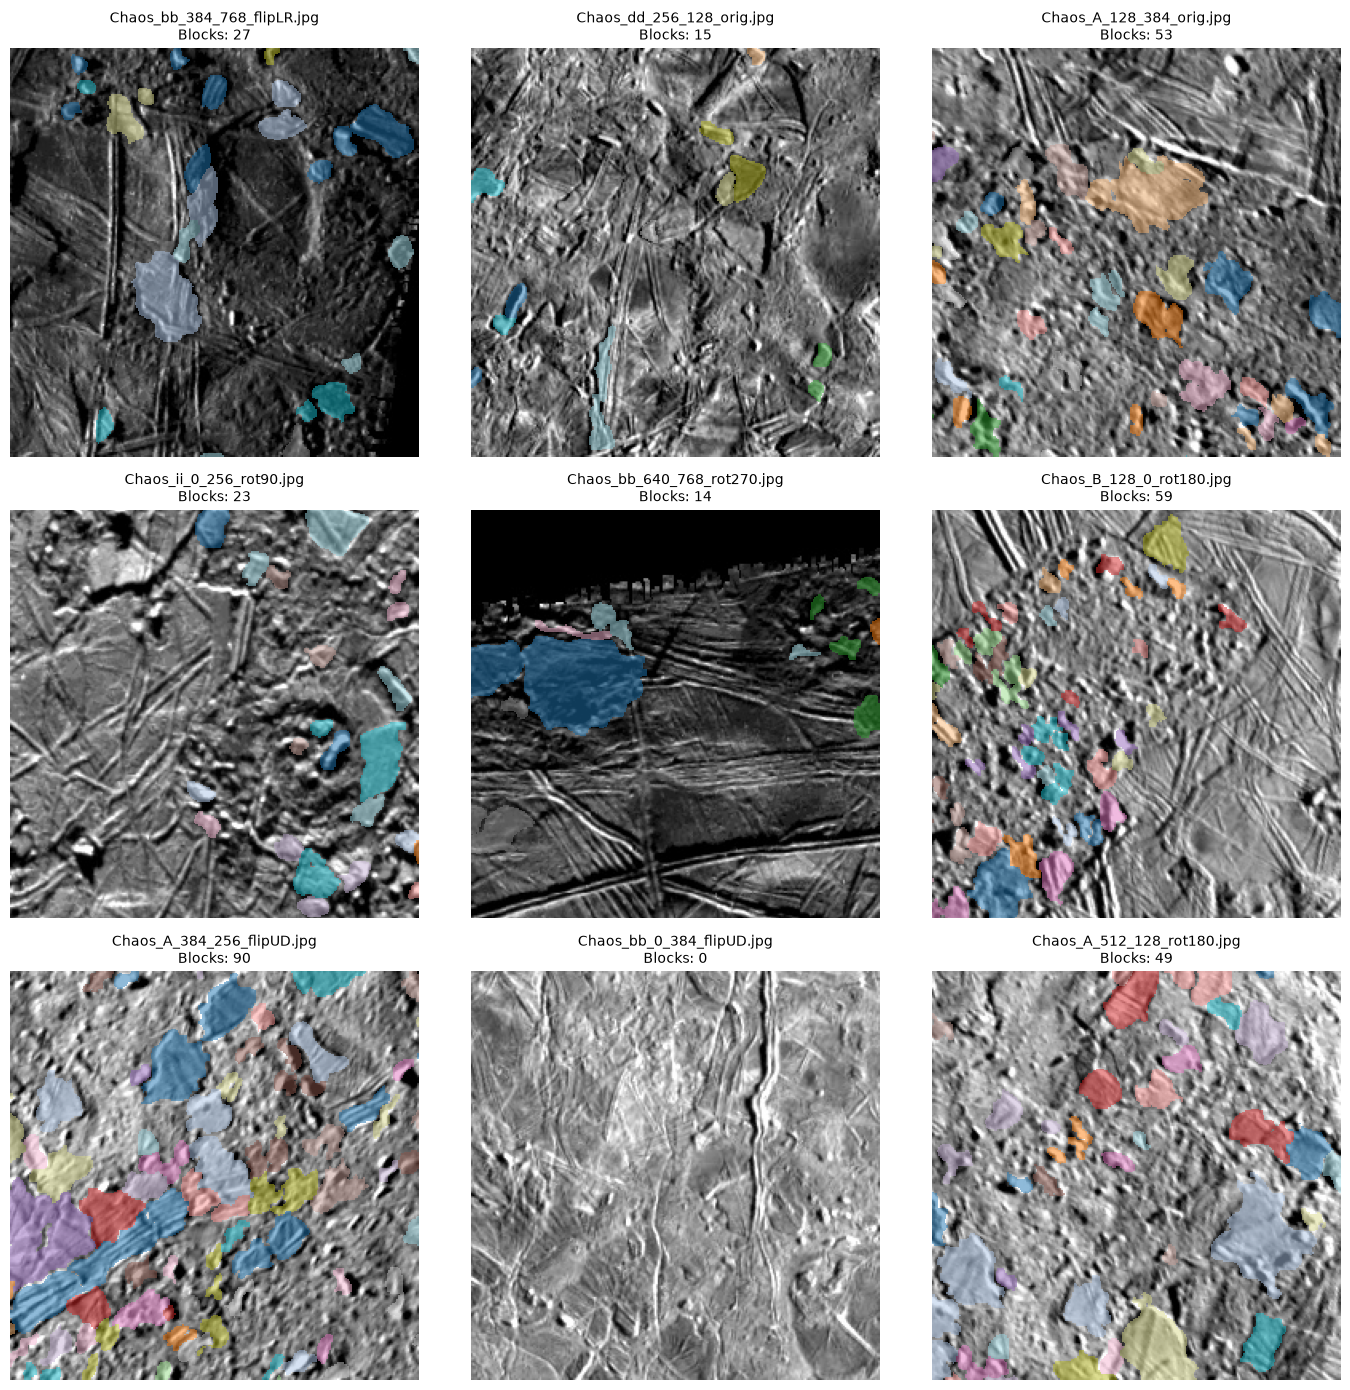

In [23]:
# plot some randomly selected tiles for visual inspection

generated_imgs = glob.glob(os.path.join(out_img_dir_fns, "*.jpg"))

# randomly select 9 chips for a 3x3 grid
sample_imgs = random.sample(generated_imgs, 9)

# create a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten() # Flattens the 3x3 matrix into a 1D list so it's easier to loop through

for i, img_path in enumerate(sample_imgs):
    basename = os.path.basename(img_path)
    mask_path = os.path.join(out_mask_dir_fns, basename.replace('.jpg', '.tif'))
    
    # read the JPG image and TIFF mask
    img = plt.imread(img_path)
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
        
    ax = axes[i]
    
    # plot the base image
    ax.imshow(img, cmap='gray')
    
    # mask out the background (0) so it becomes transparent
    transparent_mask = np.ma.masked_where(mask == 0, mask)
    
    # plot the colored blocks transparently over the image
    ax.imshow(transparent_mask, cmap='tab20', alpha=0.5, interpolation='nearest')
    
    # add title with filename and block count
    block_count = len(np.unique(mask)) - 1 if np.max(mask) > 0 else 0
    ax.set_title(f"{basename}\nBlocks: {block_count}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()